In [1]:
#impor basic library
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#loading training image

traning_image = tf.keras.utils.image_dataset_from_directory(
    'C:/Users/rizvan/Dataset_skinAi/Dataset/inceptionv3',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(299, 299),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset="training",
    interpolation="bilinear",
    follow_links=False,
    
)

Found 7001 files belonging to 5 classes.
Using 5601 files for training.


In [3]:
#loading test image

validation_image = tf.keras.utils.image_dataset_from_directory(
    'C:/Users/rizvan/Dataset_skinAi/Dataset/inceptionv3',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(299, 299),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset="validation",
    interpolation="bilinear",
    follow_links=False,
    
)

Found 7001 files belonging to 5 classes.
Using 1400 files for validation.


In [4]:
traning_image.class_names

['Acne and Rosacea',
 'Eczema',
 'Fungal infections,especilay in nails',
 'Seborrheic Keratoses or other Benign Tumors',
 'Warts Molluscum and other Viral Infections']

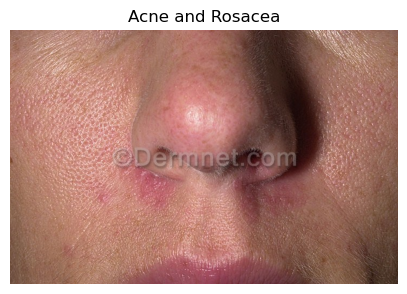

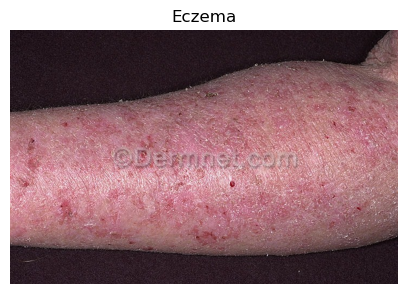

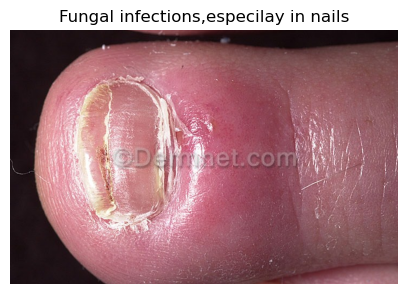

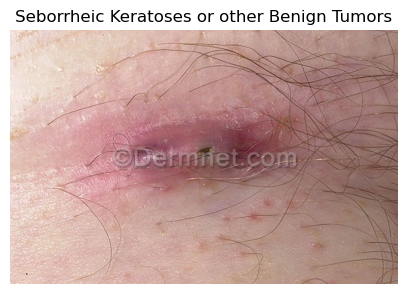

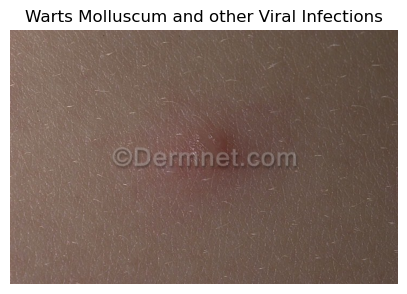

In [5]:
import os
labels = traning_image.class_names
data_dir = r'C:/Users/rizvan/Dataset_skinAi/Dataset/inceptionv3'
for label in labels:
    img = os.listdir(os.path.join(data_dir,label))[:5]
    plt.figure(figsize=(5,5))
    for i,img in enumerate(img):
        plt.imshow(plt.imread(os.path.join(data_dir,label,img)))
        plt.title(label)
        plt.axis('off')
plt.show()

In [6]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Apply normalization to the dataset
traning_image = traning_image.map(lambda x, y: (normalization_layer(x), y))
validation_image = validation_image.map(lambda x, y: (normalization_layer(x), y))

In [7]:
#modele Building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,AveragePooling2D,Dropout,GlobalAveragePooling2D,BatchNormalization,Activation
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False


In [8]:
# Create the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.6),  # Increase dropout rate
    Dense(256, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.6),  # Increase dropout rate
    Dense(5, activation='softmax')
])

In [9]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [10]:
#early stoping 
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)


In [11]:
base_model.trainable = True
for layer in base_model.layers[:-20]:  # Freeze first few layers, train last 20
    layer.trainable = False

In [12]:
model.compile(optimizer="adam",  
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [13]:
history = model.fit(traning_image, validation_data=validation_image, epochs=20,callbacks=[early_stopping, lr_scheduler])

Epoch 1/20
176/176 [==============================] - 57s 257ms/step - loss: 1.3299 - accuracy: 0.5735 - val_loss: 1.0588 - val_accuracy: 0.6736 - lr: 0.0010
Epoch 2/20
176/176 [==============================] - 40s 229ms/step - loss: 0.9733 - accuracy: 0.6918 - val_loss: 0.9314 - val_accuracy: 0.7200 - lr: 0.0010
Epoch 3/20
176/176 [==============================] - 41s 231ms/step - loss: 0.7863 - accuracy: 0.7624 - val_loss: 0.8714 - val_accuracy: 0.7421 - lr: 0.0010
Epoch 4/20
176/176 [==============================] - 41s 235ms/step - loss: 0.6632 - accuracy: 0.8057 - val_loss: 0.9233 - val_accuracy: 0.7350 - lr: 0.0010
Epoch 5/20
176/176 [==============================] - 41s 231ms/step - loss: 0.5678 - accuracy: 0.8465 - val_loss: 0.9048 - val_accuracy: 0.7521 - lr: 0.0010
Epoch 6/20
176/176 [==============================] - 41s 232ms/step - loss: 0.4777 - accuracy: 0.8823 - val_loss: 0.9219 - val_accuracy: 0.7464 - lr: 0.0010
Epoch 7/20
176/176 [==============================] 

In [14]:
train_loss =history.history['loss']
train_accuracy =history.history['accuracy']
val_loss =history.history['val_loss']
val_accuracy =history.history['val_accuracy']

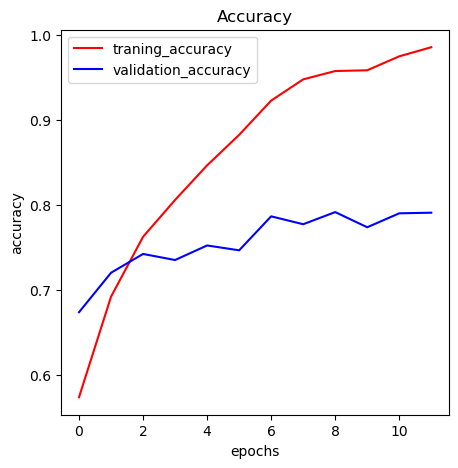

In [15]:
#plotting accuracy
plt.figure(figsize=(5,5))
plt.plot(train_accuracy,color='red',label='traning_accuracy')
plt.plot(val_accuracy,color='blue',label='validation_accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

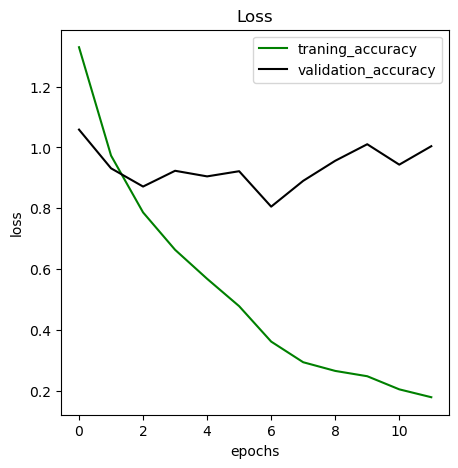

In [16]:
plt.figure(figsize=(5,5))
plt.plot(train_loss,color='green',label='traning_accuracy')
plt.plot(val_loss,color='black',label='validation_accuracy')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [17]:
y_predict = []
y_truelabel = []
for image_bt,label_batch in validation_image:
    y_truelabel.append(np.argmax(label_batch,axis=1))
    pred = model.predict(image_bt)
    y_predict.append(np.argmax(pred,axis=1))

In [18]:

y_truelabel = np.concatenate(y_truelabel)
y_predict = np.concatenate(y_predict)

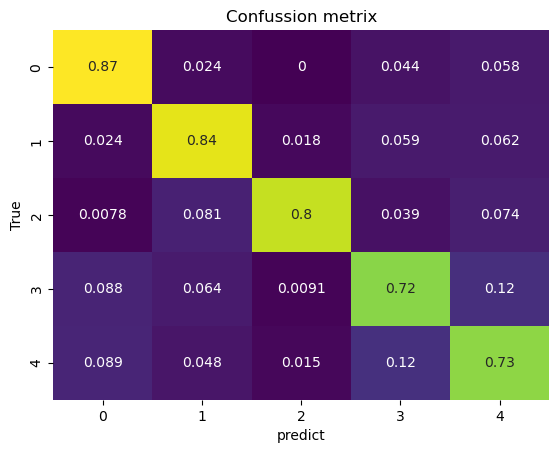

<Figure size 640x480 with 0 Axes>

In [19]:
# confussion metrix
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
con_met =confusion_matrix(y_truelabel,y_predict,normalize='true')
sns.heatmap(con_met,annot=True,cmap='viridis',cbar=None)
plt.title("Confussion metrix")
plt.ylabel('True')
plt.xlabel('predict')
plt.show()
plt.savefig('confusion_matrix_heatmap_inceptionv3.png') 

In [20]:
print(classification_report(y_truelabel,y_predict))

              precision    recall  f1-score   support

           0       0.74      0.87      0.80       206
           1       0.83      0.84      0.83       338
           2       0.94      0.80      0.86       258
           3       0.77      0.72      0.74       328
           4       0.68      0.73      0.70       270

    accuracy                           0.79      1400
   macro avg       0.79      0.79      0.79      1400
weighted avg       0.79      0.79      0.79      1400



In [22]:
# Convert history.history dictionary to a DataFrame
history_df = pd.DataFrame(history.history)

# Save the DataFrame to a CSV file
history_df.to_csv('inceptionv3_Version3.csv', index=False)

In [23]:
#saving model 
model.save('inceptionv3_Version3.h5')

In [24]:
#saving model 
model.save('inceptionv3_Version3')

INFO:tensorflow:Assets written to: inceptionv3_Version3\assets
